In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [2]:
colors = sns.cubehelix_palette(3, start=2, dark=0.3, light=0.7, hue=1, reverse=True)
colors

[[0.11279529338821315, 0.38362901931720744, 0.3441758024953217],
 [0.324595494376807, 0.5612125338635184, 0.6678787074433867],
 [0.6267938328732114, 0.7037818516209923, 0.8971944219066488]]

In [3]:
sampling_color = colors[0]
dataset_color = colors[1]
bias_color = colors[2]
alpha = 0.6
linewidth = 1.5

In [4]:
def plot_uncertainty(
    ax,
    metric,
    return_df,
    gev_spread_df,
    ylim=[],
    plot_models=False,
    letter='',
    title='',
    xlabel=True,
    ylabel=True,
    primary_bc='mean',
):
    """Plot uncertainty."""
    
    gev_spread = gev_spread_df.filter(like='model-bc-mean').mean(axis=1)
    G2 = gev_spread
    G = np.sqrt(G2)

    assert primary_bc in ['mean', 'quantile']
    model_bc_mean_spread = return_df.filter(like=f'model-bc-{primary_bc}').var(axis=1)
    M2 = model_bc_mean_spread
    M = np.sqrt(M2)
    
    B2_models = []
    for bias_method, model in return_df.filter(like='model-bc-mean').columns.values:
        B2 = return_df[[('model-bc-mean', model), ('model-bc-quantile', model)]].var(axis=1)
        B2.name = model
        B2_models.append(B2)
    B2_ensemble = pd.concat(B2_models, axis=1)
    bias_spread = B2_ensemble.mean(axis=1)
    B2 = bias_spread
    B = np.sqrt(B2)

    T2 = G2 + M2 + B2
    T = np.sqrt(T2)
    F = (G + M + B) / T

    ave_model_bc_mean = return_df.filter(like=f'model-bc-{primary_bc}').mean(axis=1)
    gev_spread_upper = ave_model_bc_mean + (1.654 * (G / F))
    gev_spread_lower = ave_model_bc_mean - (1.654 * (G / F)) 
    model_spread_upper = ave_model_bc_mean + (1.654 * ((G + M) / F))
    model_spread_lower = ave_model_bc_mean - (1.654 * ((G + M) / F))
    bias_spread_upper = ave_model_bc_mean + (1.654 * ((G + M + B) / F))
    bias_spread_lower = ave_model_bc_mean - (1.654 * ((G + M + B) / F))

    obs = return_df[('obs', 'AGCD')]
    OG2 = gev_spread_df[('obs', 'AGCD')]
    OG = np.sqrt(OG2)

    OM2 = return_df.filter(like='obs').var(axis=1)
    OM = np.sqrt(OM2)

    OT2 = OG2 + OM2
    OT = np.sqrt(OT2)
    OF = (OG + OM) / OT
    
    gev_spread_obs_upper = obs + (1.654 * (OG / OF))
    gev_spread_obs_lower = obs - (1.654 * (OG / OF)) 
    model_spread_obs_upper = obs + (1.654 * ((OG + OM) / OF))
    model_spread_obs_lower = obs - (1.654 * ((OG + OM) / OF))
    
    return_periods = return_df.index.values

    if plot_models:
        count = 0
        for model in return_df.filter(like='model-bc-mean').columns.values:
            data = return_df[model].values
            if count == 0:
                ax.plot(return_periods, data, label='individual models (mean correction)', color='#8da0cb', linewidth=0.7)
            else:
                ax.plot(return_periods, data, color='#8da0cb', linewidth=0.7)
            count = count + 1
    
    ax.plot(return_periods, obs.values, label='AGCD', color='tab:red', linewidth=linewidth+1)
#    ax.fill_between(return_periods, obs.values, gev_spread_obs_upper.values, label='GEV uncertainty (obs)', color='tab:red', alpha=alpha)
#    ax.fill_between(return_periods, gev_spread_obs_lower.values, obs.values, color='tab:red', alpha=alpha)
    ax.plot(return_periods, gev_spread_obs_upper.values, label='sampling uncertainty (AGCD)', color='tab:red', linestyle='dashed', linewidth=linewidth)
    ax.plot(return_periods, gev_spread_obs_lower.values, color='tab:red', linestyle='dashed', linewidth=linewidth)
#    ax.plot(return_periods, model_spread_obs_upper.values, label='dataset uncertainty (obs)', color='tab:red', linestyle=':', linewidth=linewidth)
#    ax.plot(return_periods, model_spread_obs_lower.values, color='tab:red', linestyle=':', linewidth=linewidth)
    
    ax.plot(return_periods, ave_model_bc_mean.values, label='multi-model mean', color='black', linewidth=linewidth+1)
#    ax.plot(return_periods, bias_spread_upper.values, label='uncertainty bounds (model)', color='black', linestyle=':')
#    ax.plot(return_periods, bias_spread_lower.values, color='black', linestyle=':')
    
    ax.fill_between(return_periods, ave_model_bc_mean.values, gev_spread_upper.values, label='sampling uncertainty (models)', color=sampling_color, alpha=alpha)
    ax.fill_between(return_periods, gev_spread_lower.values, ave_model_bc_mean.values, color=sampling_color, alpha=alpha)
    ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='dataset uncertainty (models)', color=dataset_color, alpha=alpha)
    ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color=dataset_color, alpha=alpha)
    ax.fill_between(return_periods, model_spread_upper.values, bias_spread_upper.values, label='bias uncertainty (models)', color=bias_color, alpha=alpha)
    ax.fill_between(return_periods, bias_spread_lower.values, model_spread_lower.values, color=bias_color, alpha=alpha)

    legsize = 'x-large' if metric == 'rx1day' else 'large'
    ax.legend(fontsize=legsize)
    ax.set_xscale('log')
    if xlabel:
        ax.set_xlabel('return period (years)')
    if ylabel:
        metric_label = {'txx': 'TXx ($^\circ$C)', 'rx1day': 'Rx1day (mm)'}
        ax.set_ylabel(f'{metric_label[metric]}')
    if letter:
        yloc = 0.05 if metric == 'rx1day' else 0.93
        ax.text(0.05, yloc, f'({letter})', transform=ax.transAxes, fontsize='xx-large')
    if title:
        ax.set_title(title)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

In [5]:
def plot_fraction(
    ax,
    return_df,
    gev_spread_df,
    xmin=1,
    title='',
    ylabel=True,
    xlabel=True,
):
    """Plot fraction."""

    gev_spread = gev_spread_df.filter(like='model-bc-mean').mean(axis=1)
    G2 = gev_spread
    
    model_bc_mean_spread = return_df.filter(like='model-bc-mean').var(axis=1)
    M2 = model_bc_mean_spread
        
    B2_models = []
    for bias_method, model in return_df.filter(like='model-bc-mean').columns.values:
        B2 = return_df[[('model-bc-mean', model), ('model-bc-quantile', model)]].var(axis=1)
        B2.name = model
        B2_models.append(B2)
    B2_ensemble = pd.concat(B2_models, axis=1)
    bias_spread = B2_ensemble.mean(axis=1)
    B2 = bias_spread
    
    T2 = G2 + M2 + B2
    
    B2_frac = B2 / T2
    M2_frac = M2 / T2
    G2_frac = G2 / T2
    
    return_periods = return_df.index.values
    
    ax.fill_between(
        return_periods,
        G2_frac.values + M2_frac.values + B2_frac.values,
        G2_frac.values + M2_frac.values,
        label='bias correction uncertainty',
        color=bias_color,
    )
    ax.fill_between(return_periods, G2_frac.values + M2_frac.values, G2_frac.values, label='dataset uncertainty', color=dataset_color)
    ax.fill_between(return_periods, G2_frac.values, label='sampling uncertainty', color=sampling_color)
    ax.plot(return_periods, G2_frac.values, color='black')
    ax.plot(return_periods, G2_frac.values + M2_frac.values, color='black')
    
    ax.legend()
    ax.set_xscale('log')
    if xlabel:
        ax.set_xlabel('return period (years)')
    if ylabel:
        ax.set_ylabel('Fraction of total variance')
    if title:
        ax.set_title(title)
    ax.set_ylim([0, 1.0])
    ax.set_xlim([xmin, 1e4])
    ax.grid(which='both')

## rx1day

In [6]:
location1 = [3, 8]
model_dict1 = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}

return_df1, gev_spread_df1 = utils.get_return_values('rx1day', location1, model_dict1)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CAFE
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: CanESM5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MIROC6
INFO:root:start: MPI-ESM1-2-HR
INFO:root:start: MRI-ESM2-0
INFO:root:start: NorCPM1


In [7]:
location2 = [7, 11]
model_dict2 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
#    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
#    'MRI-ESM2-0': 'tab:olive',
#    'NorCPM1': 'tab:cyan',
}
return_df2, gev_spread_df2 = utils.get_return_values('rx1day', location2, model_dict2)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MIROC6
INFO:root:start: MPI-ESM1-2-HR


In [8]:
location3 = [0, 11]
model_dict3 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df3, gev_spread_df3 = utils.get_return_values('rx1day', location3, model_dict3)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: CanESM5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MIROC6
INFO:root:start: MPI-ESM1-2-HR
INFO:root:start: MRI-ESM2-0
INFO:root:start: NorCPM1


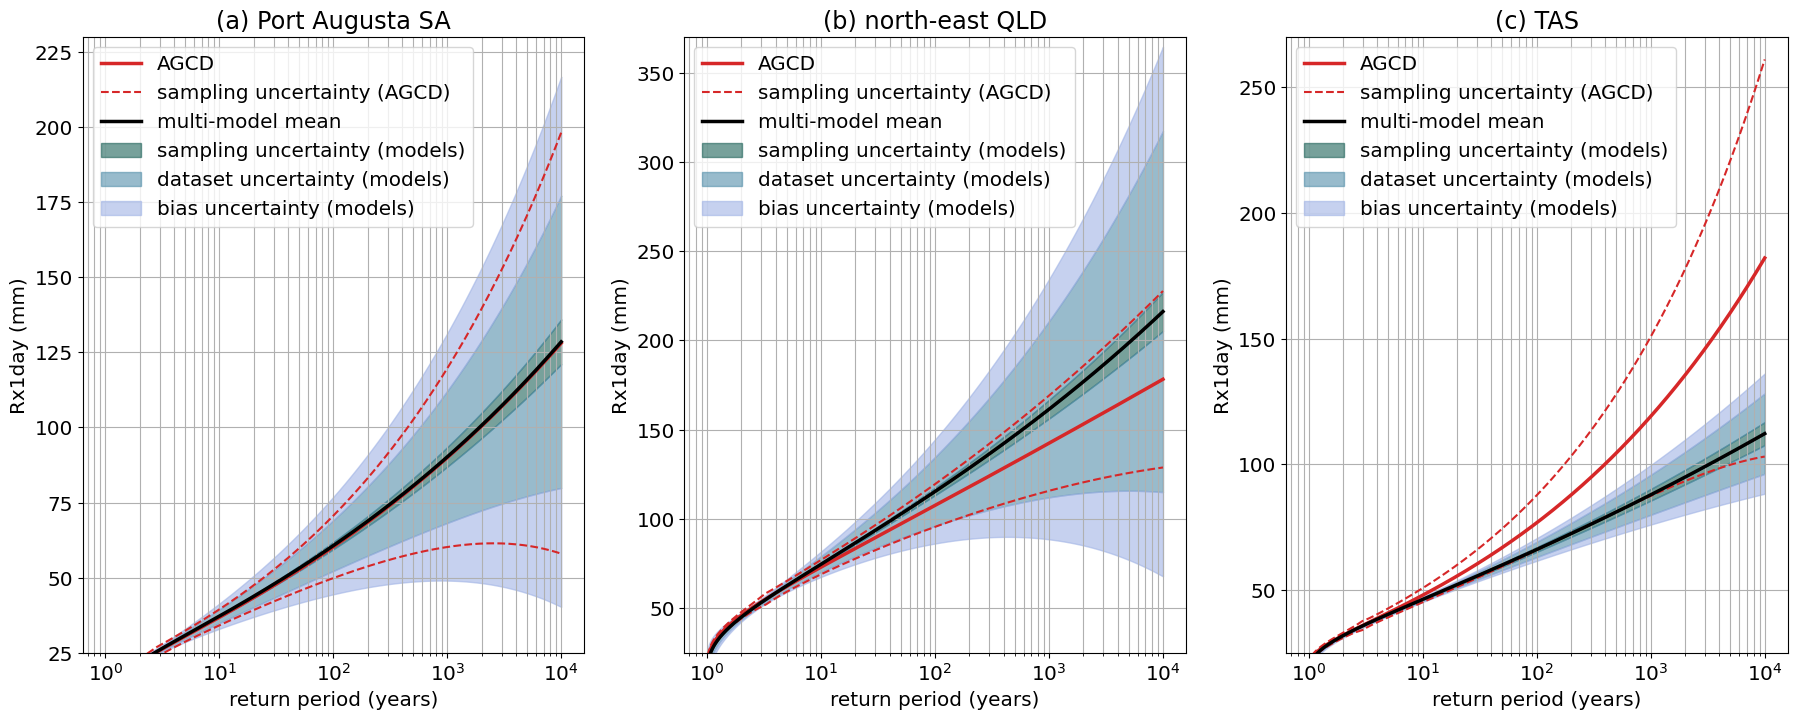

In [37]:
fig = plt.figure(figsize=[22, 8])

ax1 = fig.add_subplot(131)
plot_uncertainty(ax1, 'rx1day', return_df1, gev_spread_df1, ylim=[25, 230], title='(a) Port Augusta SA')

ax2 = fig.add_subplot(132)
plot_uncertainty(ax2, 'rx1day', return_df2, gev_spread_df2, ylim=[25, 370], title='(b) north-east QLD')

ax3 = fig.add_subplot(133)
plot_uncertainty(ax3, 'rx1day', return_df3, gev_spread_df3, ylim=[25, 270], title='(c) TAS')

plt.savefig('figures/rx1day_uncertainty.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

## TXx

In [27]:
location4 = [5, 13]
model_dict4 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
#    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df4, gev_spread_df4 = utils.get_return_values('txx', location4, model_dict4)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: CanESM5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MPI-ESM1-2-HR
INFO:root:start: MRI-ESM2-0
INFO:root:start: NorCPM1


In [28]:
location5 = [2, 9]
model_dict5 = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df5, gev_spread_df5 = utils.get_return_values('txx', location5, model_dict5)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CAFE
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: CanESM5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MIROC6
INFO:root:start: MPI-ESM1-2-HR
INFO:root:start: MRI-ESM2-0
INFO:root:start: NorCPM1


In [29]:
location6 = [4, 2]
model_dict6 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
#    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df6, gev_spread_df6 = utils.get_return_values('txx', location6, model_dict6)

INFO:root:start: BCC-CSM2-MR
INFO:root:start: CMCC-CM2-SR5
INFO:root:start: CanESM5
INFO:root:start: EC-Earth3
INFO:root:start: IPSL-CM6A-LR
INFO:root:start: MPI-ESM1-2-HR
INFO:root:start: MRI-ESM2-0
INFO:root:start: NorCPM1


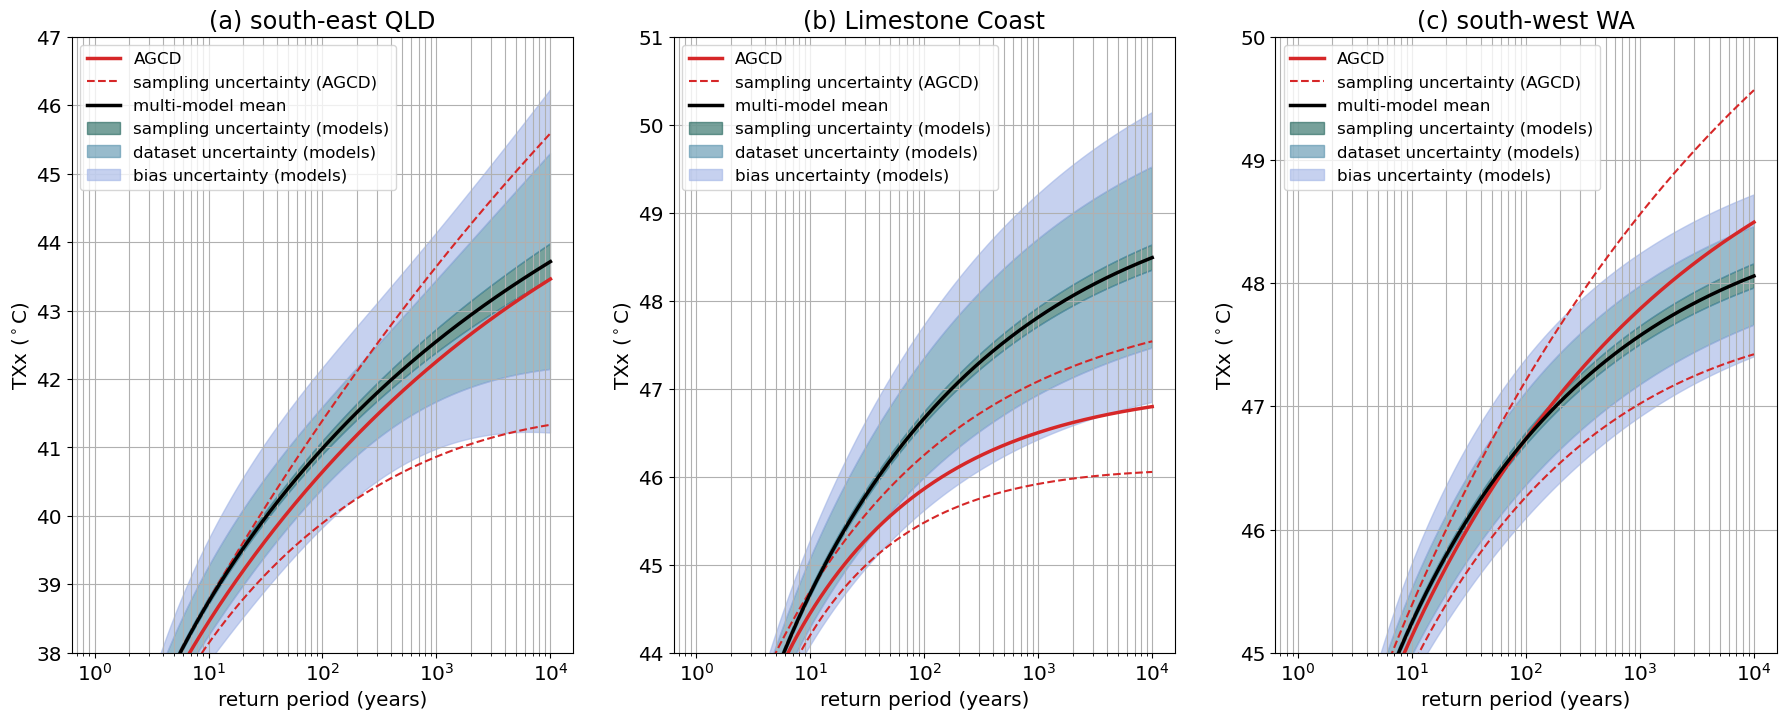

In [32]:
fig = plt.figure(figsize=[22, 8])

ax4 = fig.add_subplot(131)
plot_uncertainty(ax4, 'txx', return_df4, gev_spread_df4, ylim=[38, 47], title='(a) south-east QLD')

ax5 = fig.add_subplot(132)
plot_uncertainty(ax5, 'txx', return_df5, gev_spread_df5, ylim=[44, 51], title='(b) Limestone Coast')

ax6 = fig.add_subplot(133)
plot_uncertainty(ax6, 'txx', return_df6, gev_spread_df6, ylim=[45, 50], title='(c) south-west WA')

plt.savefig('figures/txx_uncertainty.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

## Combined

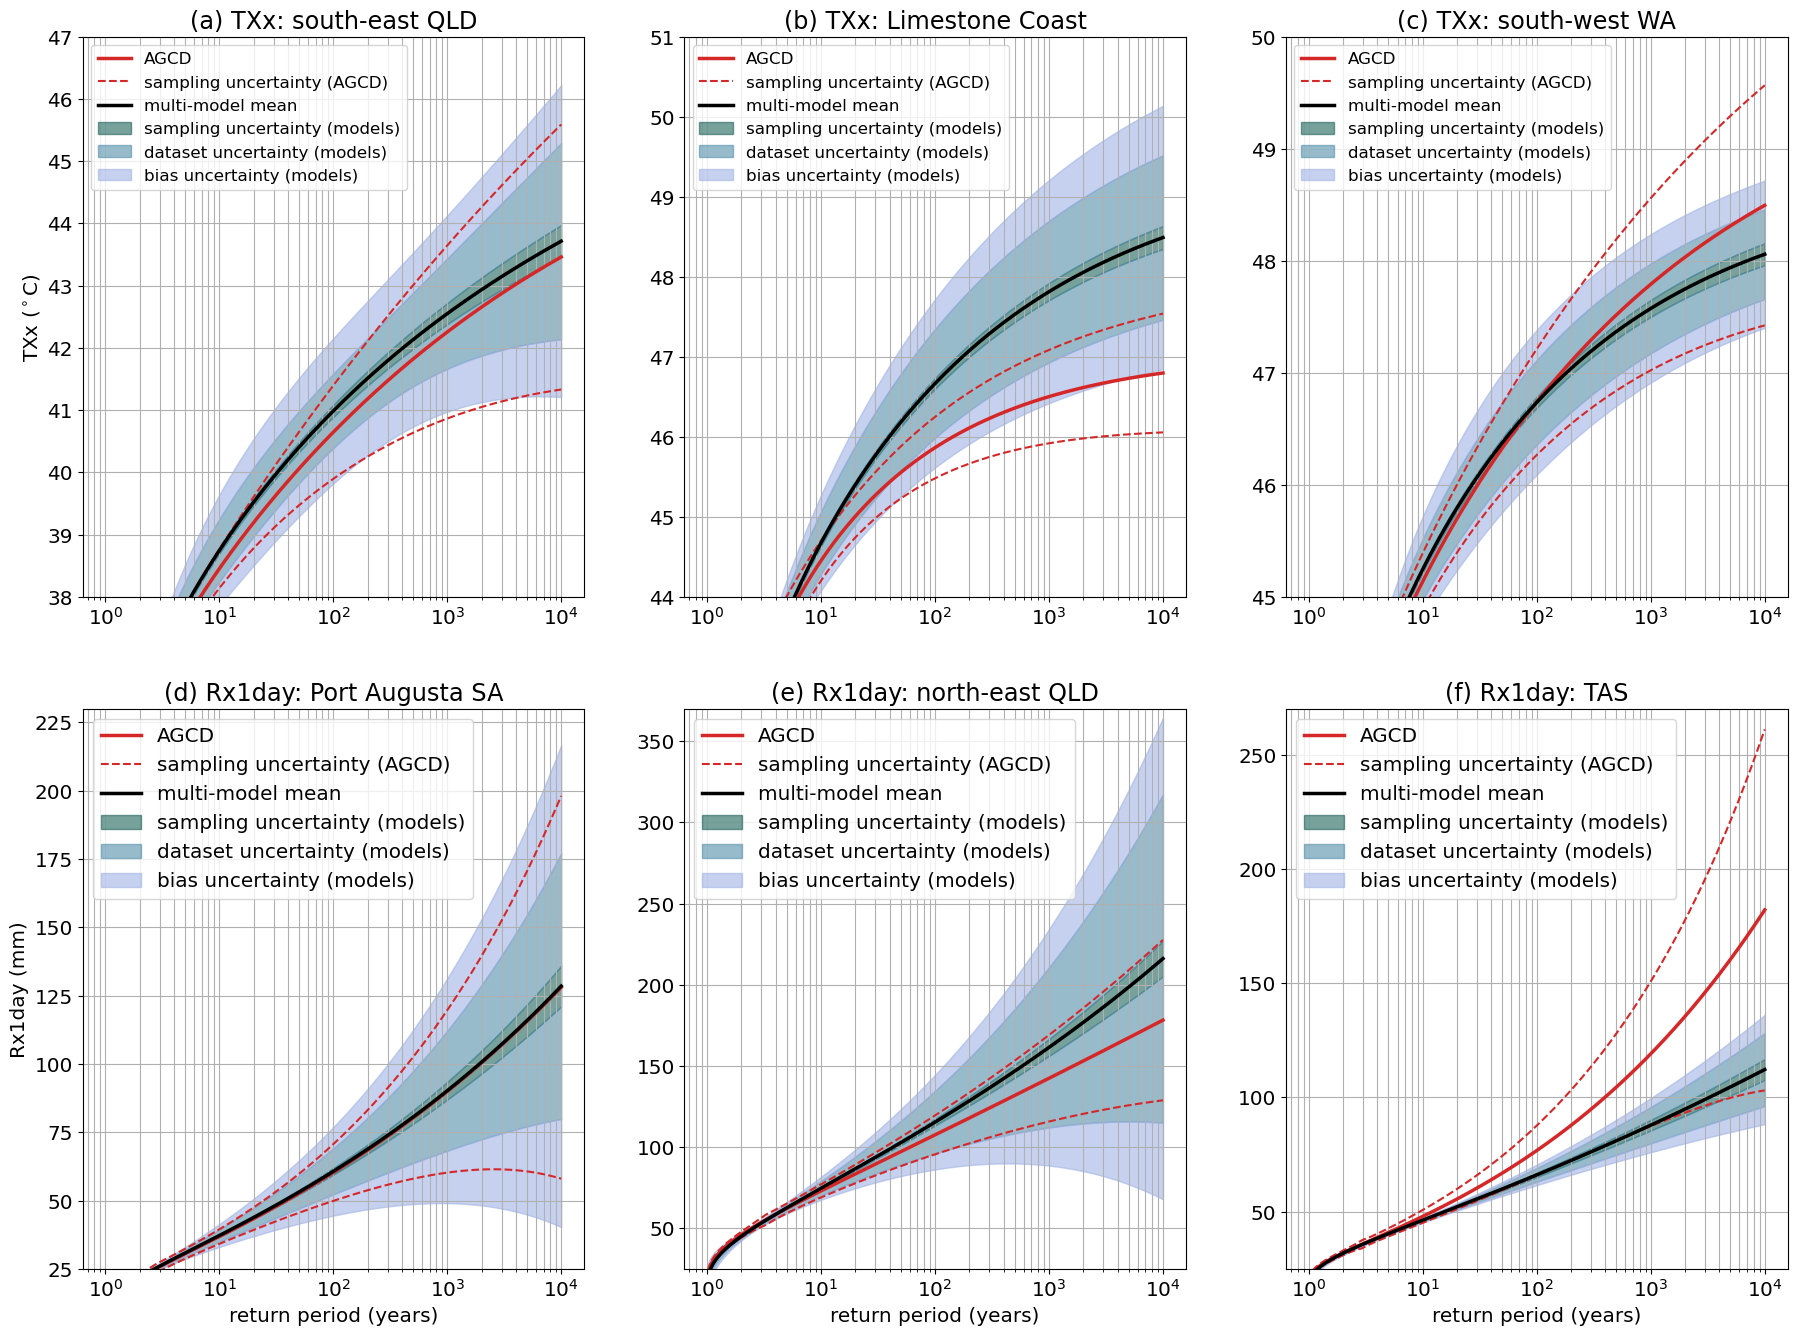

In [36]:
fig = plt.figure(figsize=[22, 16])

ax4 = fig.add_subplot(231)
plot_uncertainty(ax4, 'txx', return_df4, gev_spread_df4, ylim=[38, 47], title='(a) TXx: south-east QLD', xlabel=False)

ax5 = fig.add_subplot(232)
plot_uncertainty(ax5, 'txx', return_df5, gev_spread_df5, ylim=[44, 51], title='(b) TXx: Limestone Coast', xlabel=False, ylabel=False)

ax6 = fig.add_subplot(233)
plot_uncertainty(ax6, 'txx', return_df6, gev_spread_df6, ylim=[45, 50], title='(c) TXx: south-west WA', xlabel=False, ylabel=False)

ax1 = fig.add_subplot(234)
plot_uncertainty(ax1, 'rx1day', return_df1, gev_spread_df1, ylim=[25, 230], title='(d) Rx1day: Port Augusta SA')

ax2 = fig.add_subplot(235)
plot_uncertainty(ax2, 'rx1day', return_df2, gev_spread_df2, ylim=[25, 370], title='(e) Rx1day: north-east QLD', ylabel=False)

ax3 = fig.add_subplot(236)
plot_uncertainty(ax3, 'rx1day', return_df3, gev_spread_df3, ylim=[25, 270], title='(f) Rx1day: TAS', ylabel=False)

plt.savefig('figures/point_uncertainty.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

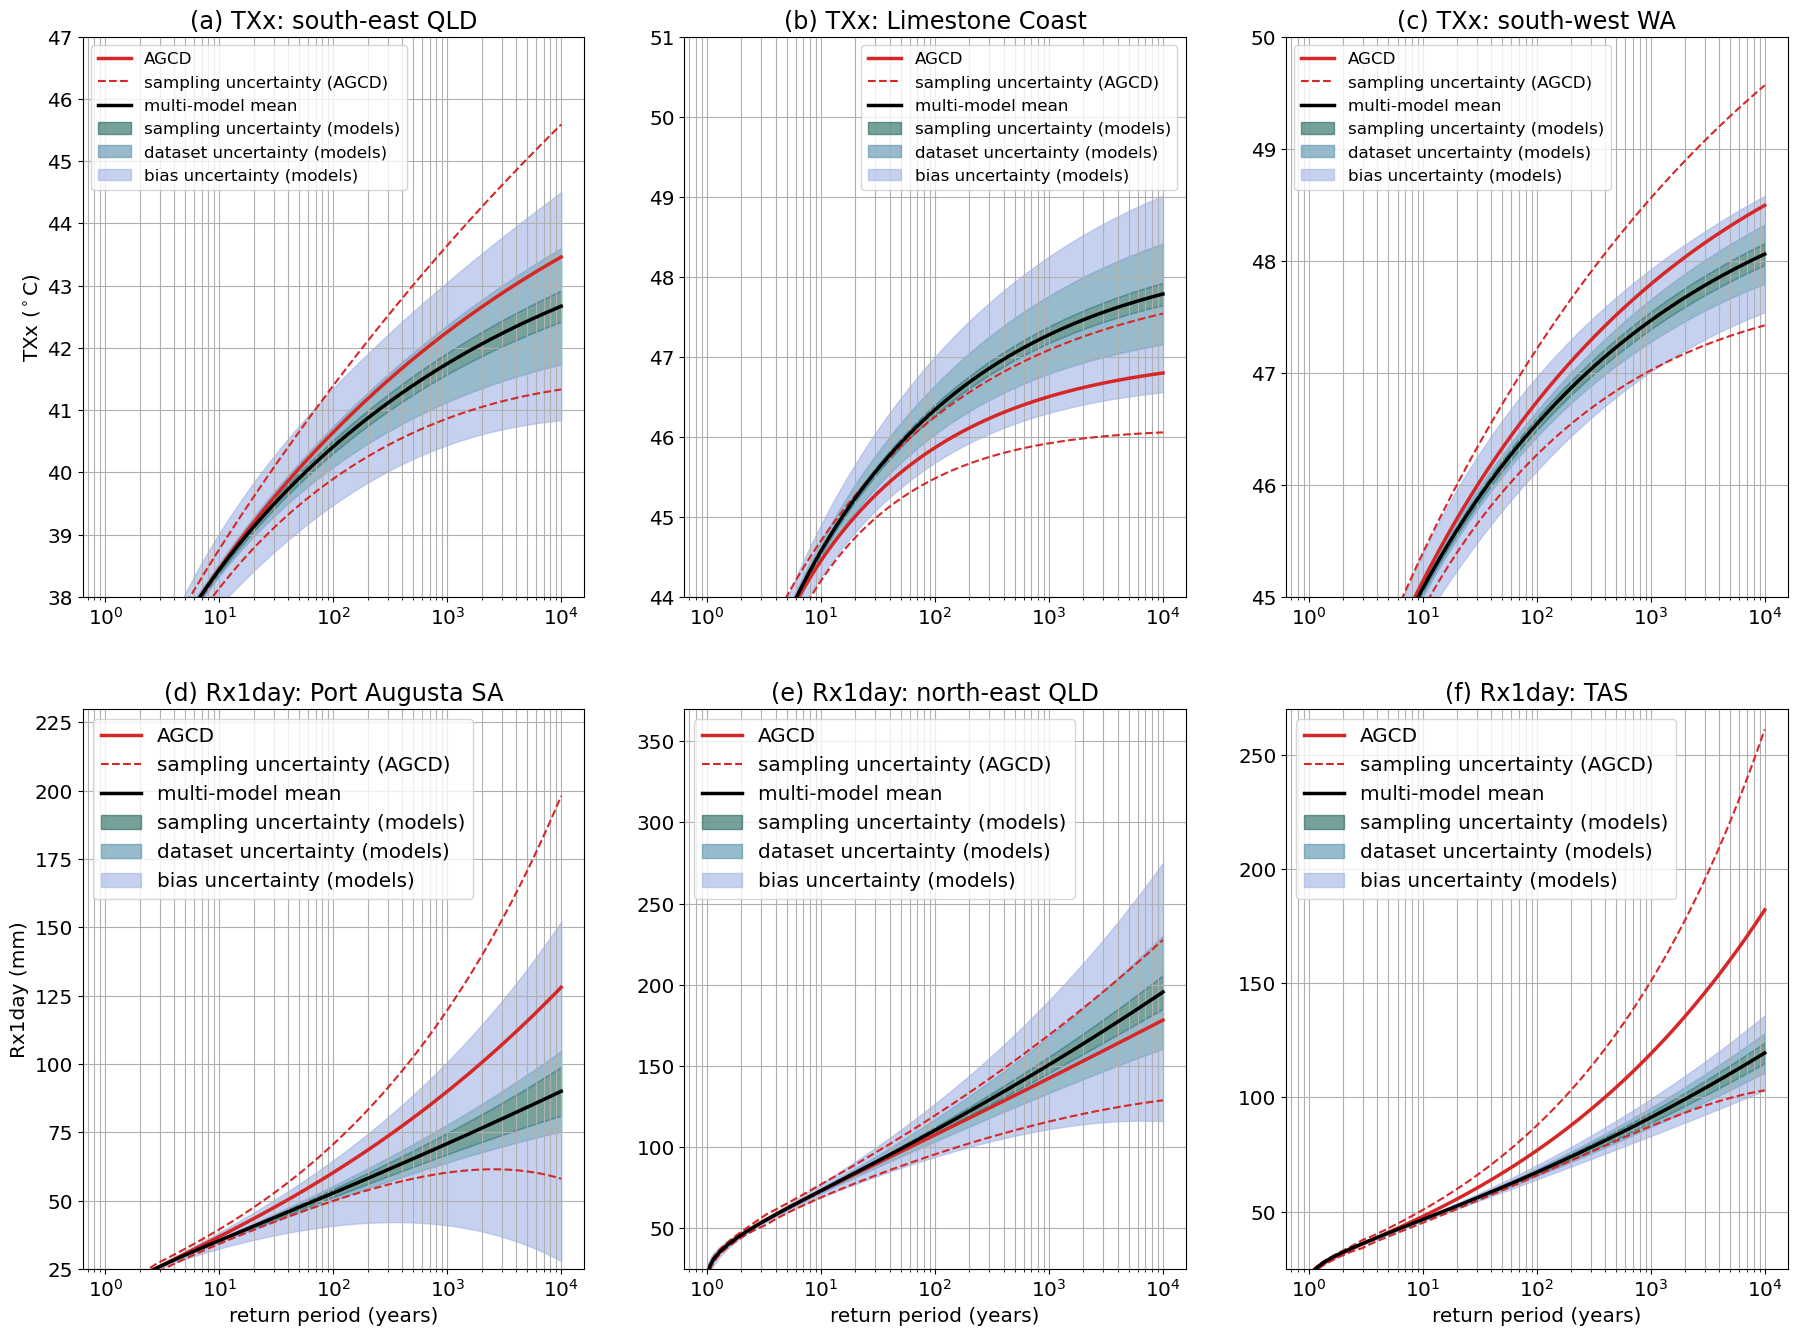

In [38]:
fig = plt.figure(figsize=[22, 16])

ax4 = fig.add_subplot(231)
plot_uncertainty(ax4, 'txx', return_df4, gev_spread_df4, ylim=[38, 47], title='(a) TXx: south-east QLD', xlabel=False, primary_bc='quantile')

ax5 = fig.add_subplot(232)
plot_uncertainty(ax5, 'txx', return_df5, gev_spread_df5, ylim=[44, 51], title='(b) TXx: Limestone Coast', xlabel=False, ylabel=False, primary_bc='quantile')

ax6 = fig.add_subplot(233)
plot_uncertainty(ax6, 'txx', return_df6, gev_spread_df6, ylim=[45, 50], title='(c) TXx: south-west WA', xlabel=False, ylabel=False, primary_bc='quantile')

ax1 = fig.add_subplot(234)
plot_uncertainty(ax1, 'rx1day', return_df1, gev_spread_df1, ylim=[25, 230], title='(d) Rx1day: Port Augusta SA', primary_bc='quantile')

ax2 = fig.add_subplot(235)
plot_uncertainty(ax2, 'rx1day', return_df2, gev_spread_df2, ylim=[25, 370], title='(e) Rx1day: north-east QLD', ylabel=False, primary_bc='quantile')

ax3 = fig.add_subplot(236)
plot_uncertainty(ax3, 'rx1day', return_df3, gev_spread_df3, ylim=[25, 270], title='(f) Rx1day: TAS', ylabel=False, primary_bc='quantile')

plt.savefig('figures/point_uncertainty_quantile.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

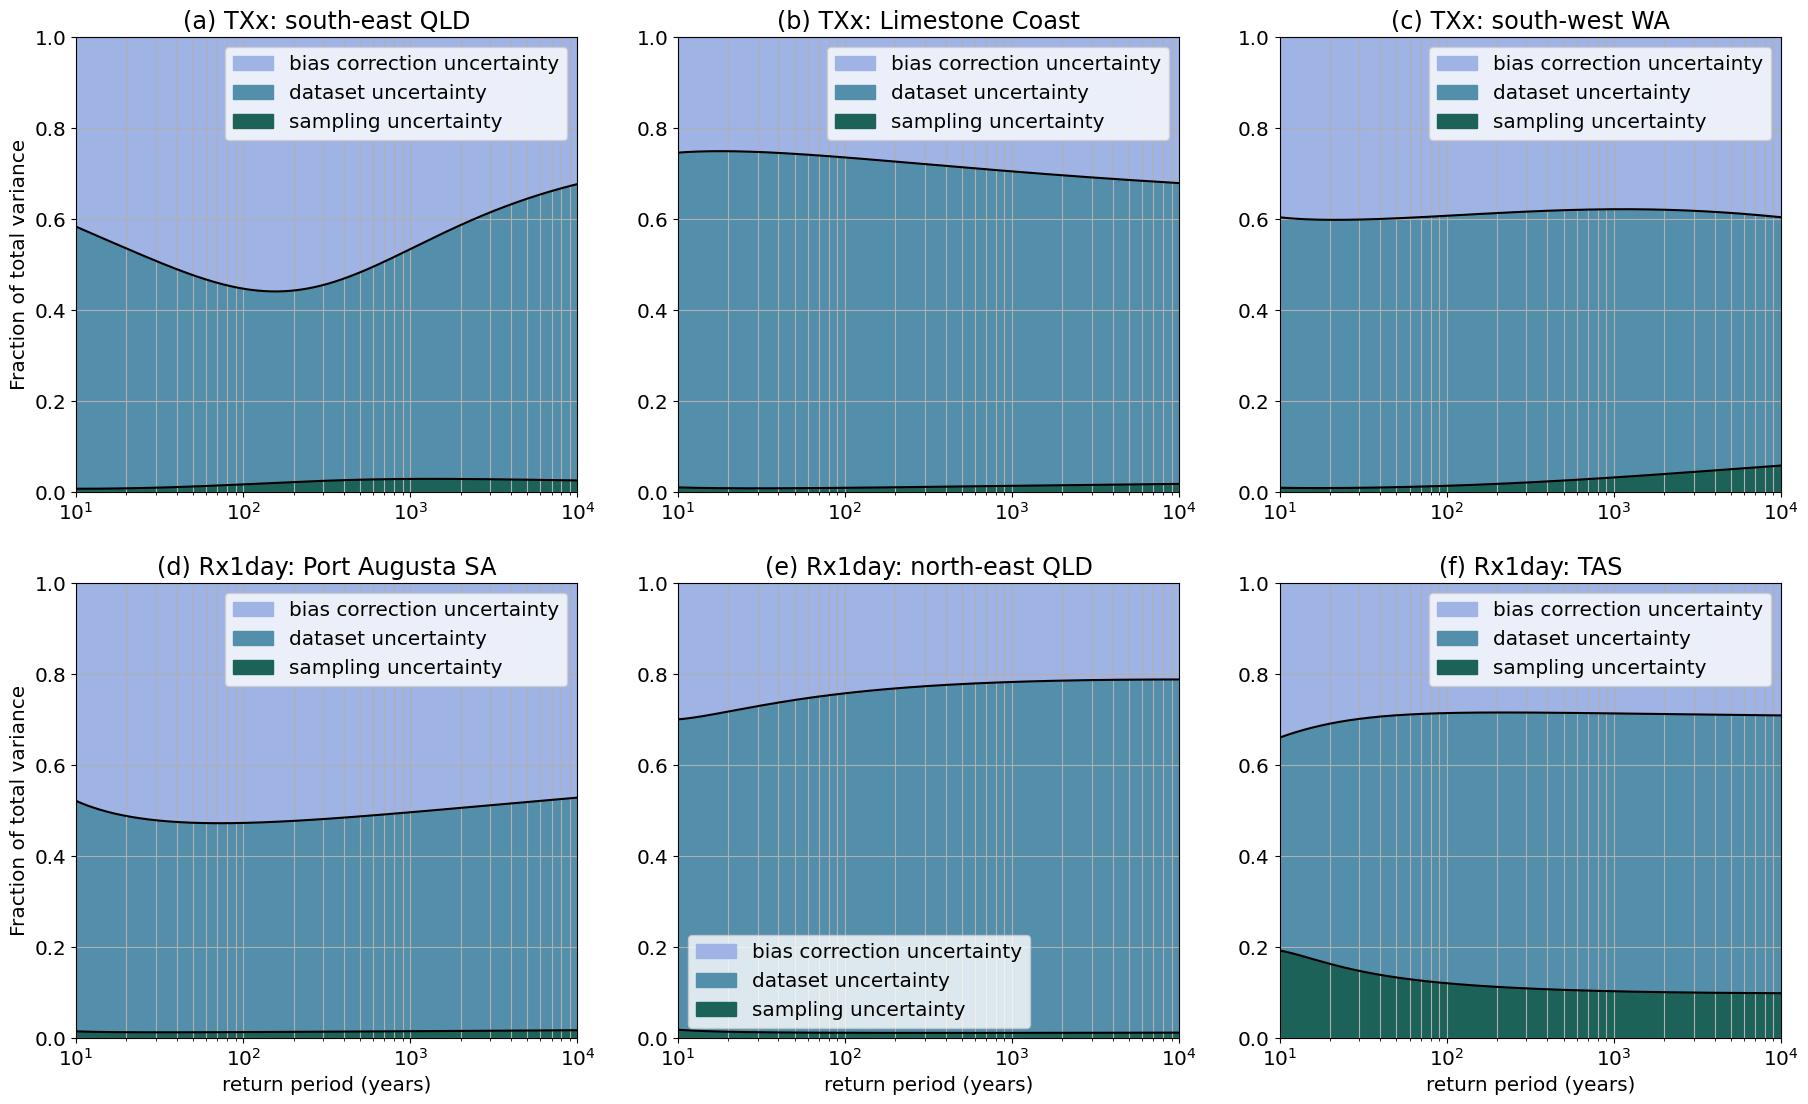

In [39]:
fig = plt.figure(figsize=[22, 13])
xmin = 10

ax4 = fig.add_subplot(231)
plot_fraction(ax4, return_df4, gev_spread_df4, title='(a) TXx: south-east QLD', xmin=xmin, xlabel=False)

ax5 = fig.add_subplot(232)
plot_fraction(ax5, return_df5, gev_spread_df5, title='(b) TXx: Limestone Coast', xmin=xmin, ylabel=False, xlabel=False)

ax6 = fig.add_subplot(233)
plot_fraction(ax6, return_df6, gev_spread_df6, title='(c) TXx: south-west WA', xmin=xmin, ylabel=False, xlabel=False)

ax1 = fig.add_subplot(234)
plot_fraction(ax1, return_df1, gev_spread_df1, title='(d) Rx1day: Port Augusta SA', xmin=xmin)

ax2 = fig.add_subplot(235)
plot_fraction(ax2, return_df2, gev_spread_df2, title='(e) Rx1day: north-east QLD', xmin=xmin, ylabel=False)

ax3 = fig.add_subplot(236)
plot_fraction(ax3, return_df3, gev_spread_df3, title='(f) Rx1day: TAS', xmin=xmin, ylabel=False)

plt.savefig('figures/point_fractions.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()